In [10]:
#!/usr/bin/env python
# coding: utf-8

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from statistics import mean

from data_utils import *

In [11]:
label_cols = ["cohesion", "syntax", "vocabulary", "phraseology", "grammar", "conventions"]

df = pd.read_csv('../../input/feedback-prize-english-language-learning/train_fold4_len_unique_words.csv')

print(df.shape)
df.head()

(3911, 13)


,text_id,full_text,cohesion,syntax,vocabulary,phraseology,grammar,conventions,token_len,token_bins,unique_word_len,unique_word_bins,fold
0,0016926B079C,I think that students would benefit from learn...,3.5,3.5,3.0,3.0,4.0,3.0,261,7,144,11,2
1,0022683E9EA5,When a problem is a change you have to let it ...,2.5,2.5,3.0,2.0,2.0,2.5,533,16,151,12,3
2,00299B378633,"Dear, Principal\n\nIf u change the school poli...",3.0,3.5,3.0,3.0,3.0,2.5,320,9,136,10,1
3,003885A45F42,The best time in life is when you become yours...,4.5,4.5,4.5,4.5,4.0,5.0,728,22,260,21,2
4,0049B1DF5CCC,Small act of kindness can impact in other peop...,2.5,3.0,3.0,3.0,2.5,2.5,234,7,106,8,2


In [13]:
df.groupby(['fold'])[label_cols + ['token_len', 'unique_word_len']].agg(['mean', 'std', 'count'])

cohesion                    syntax                 vocabulary            \
          mean       std count      mean       std count       mean       std   
fold                                                                            
0     3.138037  0.659832   978  3.033742  0.646925   978   3.237219  0.582028   
1     3.112590  0.673423   977  3.009724  0.640710   977   3.228250  0.583763   
2     3.112986  0.650773   978  3.021472  0.639496   978   3.232618  0.576608   
3     3.144683  0.666325   978  3.048057  0.650754   978   3.244888  0.590872   

           phraseology  ... grammar conventions                   token_len  \
     count        mean  ...   count        mean       std count        mean   
fold                    ...                                                   
0      978    3.132924  ...     978    3.076687  0.676592   978  437.180982   
1      977    3.110542  ...     977    3.076254  0.664582   977  436.567042   
2      978    3.111452  ...     978    3.079243  0.661183   978  425.523517   
3      978    3.112474  ...     978    3.092025  0.684092   978  422.706544   

                       unique_word_len                   
             std count            mean        std count  
fold                                                     
0     201.183431   978      175.302658  62.356032   978  
1     194.370953   977      174.547595  60.491261   977  
2     188.764447   978      171.308793  57.893001   978  
3     182.521503   978      171.915133  58.934031   978  

[4 rows x 24 columns]

<AxesSubplot:xlabel='token_bins', ylabel='count'>

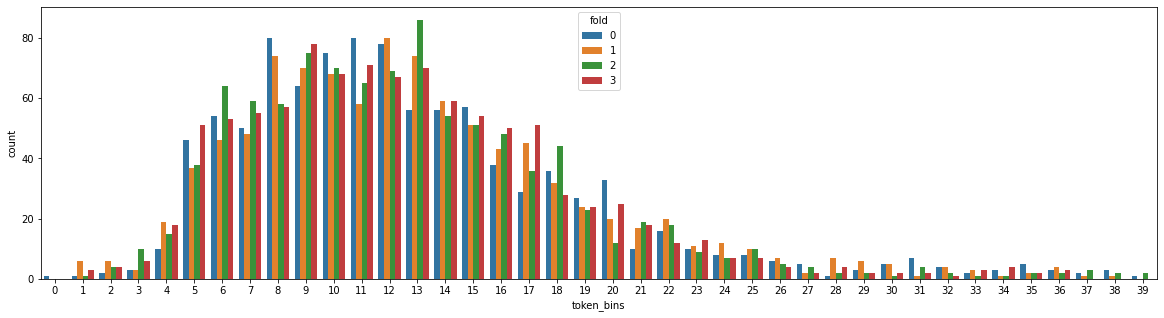

In [6]:
fig, axes = plt.subplots(1, 1, figsize=(20, 5))
sns.countplot(x="token_bins", data=df, hue="fold")

<AxesSubplot:xlabel='unique_word_bins', ylabel='count'>

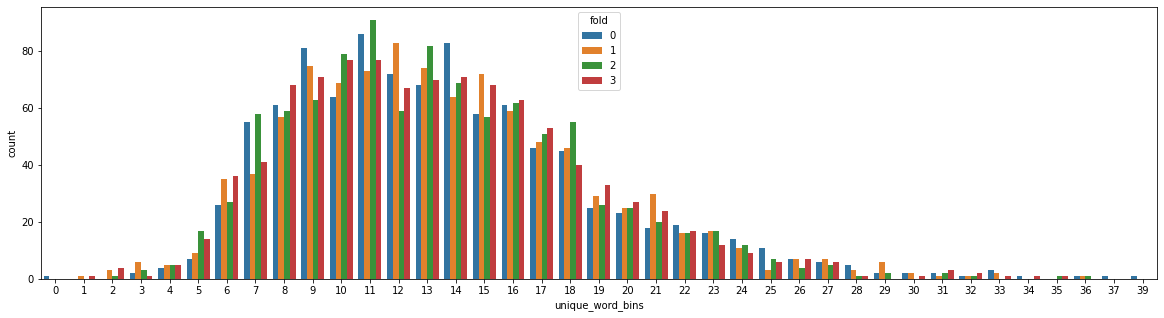

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(20, 5))
sns.countplot(x="unique_word_bins", data=df, hue="fold")

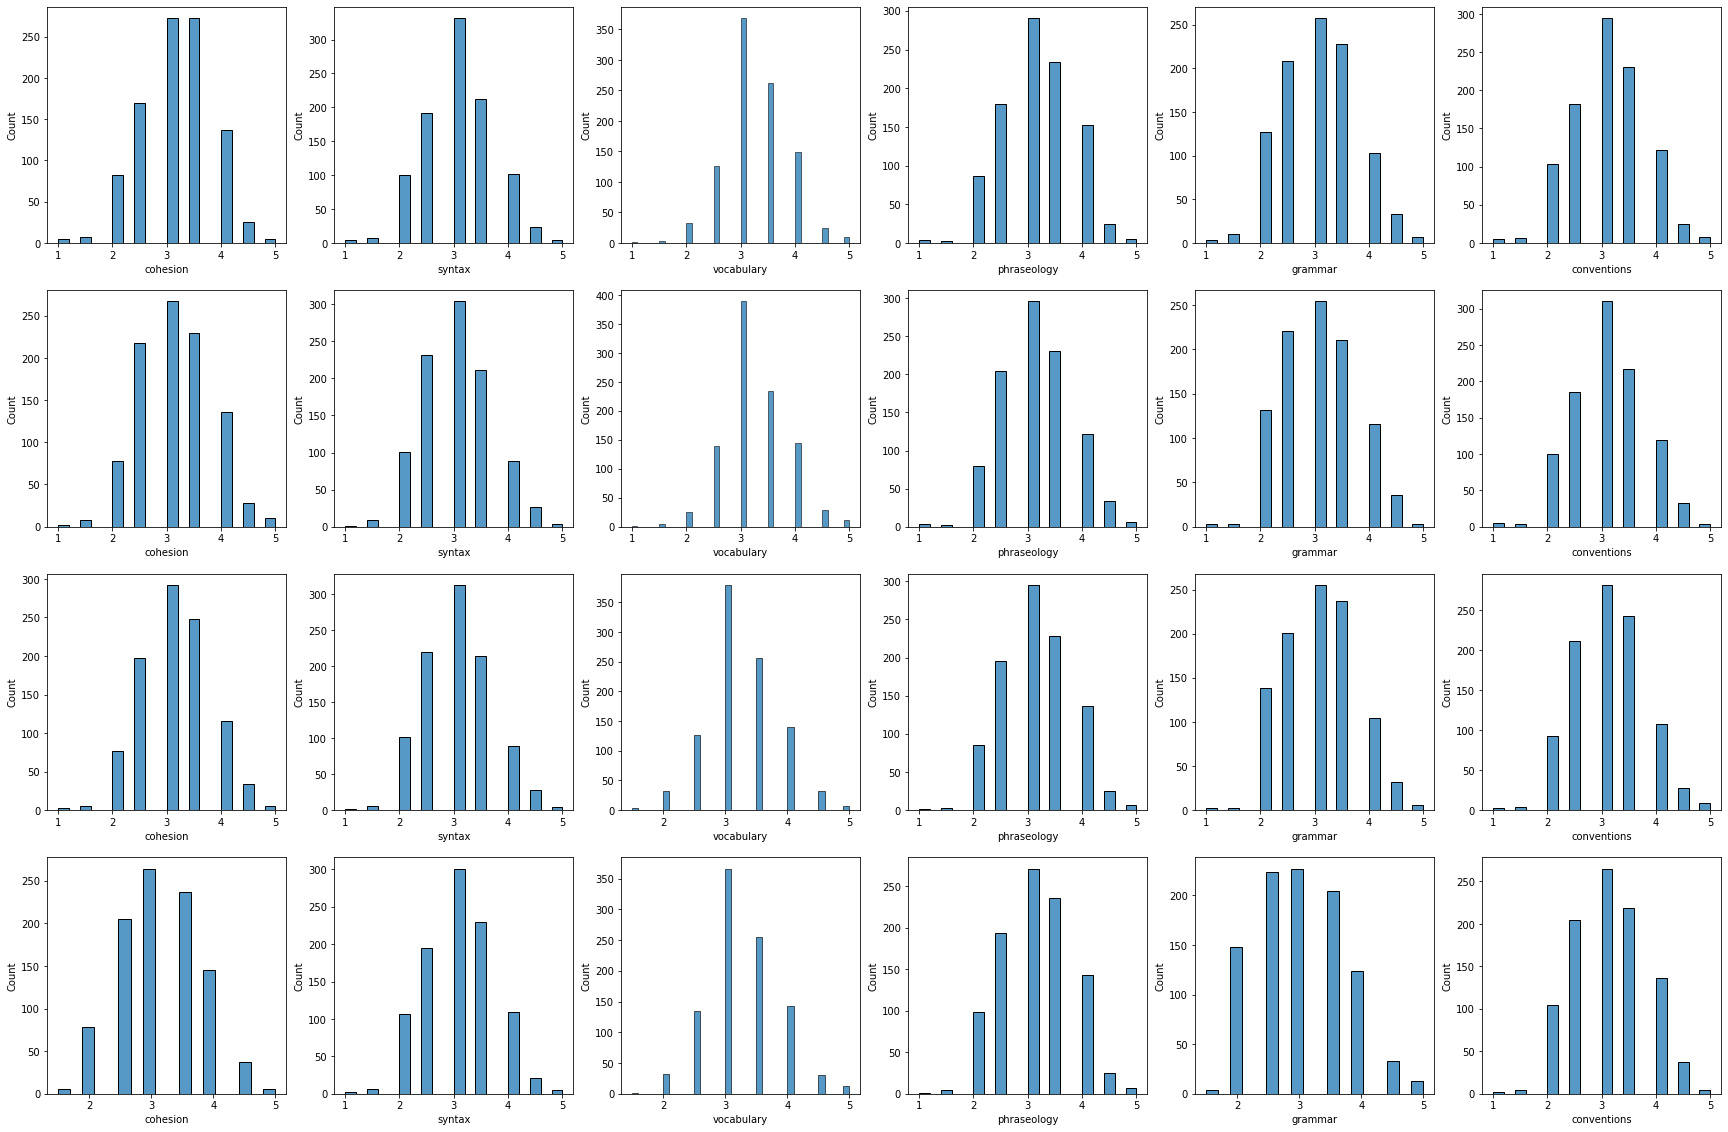

In [16]:
n_folds = 4

rows = n_folds
cols = len(label_cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5))

for row_idx, fold in enumerate(range(n_folds)):
    for col_idx, label in enumerate(label_cols):
        df_fold = df[df['fold'] == fold]
        sns.histplot(x=label, data=df_fold, ax=axes[row_idx, col_idx])